# GraphCast: ERA5 climatology (2m temperature)

Produces the two 30-year 2m-temperature climatology files (1992-2021) that
`plot_forecast_errors.ipynb` uses to normalize its skill scores.

Adapted from ERA5 data-preparation code by **Emily Morris**.

## Config


In [2]:
import sys, os
sys.path.insert(0, "../common")
from zenodo_fetch import ensure_zenodo_files

DATA_DIR = "../data/GraphCast/climatology"
os.makedirs(DATA_DIR, exist_ok=True)

# Set True to re-derive the climatology from the raw ~30-year public ERA5
# archive instead of using the cached/downloaded file (see the "[OPTIONAL]"
# section below). This is a large reduction over ~30 years of hourly data --
# heavy on memory and time. Leave False unless you specifically need to
# regenerate it.
REGENERATE_FROM_SCRATCH = False


## Get the climatology (default: fetch precomputed files)


In [3]:
# --- TEMPORARY: data is on Zenodo's sandbox while the paper is under review ---
# Sandbox records are periodically wiped and their DOIs (10.5072/...) are not
# real. When the record is published on the real Zenodo, delete these two lines
# and replace the record id(s) below with the real one(s).
import os
os.environ["ZENODO_BASE_URL"] = "https://sandbox.zenodo.org"
# -----------------------------------------------------------------------------

# Zenodo record holding GraphCast's ERA5, climatology and simulation-input
# data. See README.md for what each record contains.
ZENODO_RECORD_GRAPHCAST_ERA5 = "586387"

ensure_zenodo_files(ZENODO_RECORD_GRAPHCAST_ERA5, {
    "std_dev_30yr_climatology_1992_to_2021.nc": "726ab93a6dd57098a6e37536b41ea441",
    "temp_climatology_timeseries_1992_to_2021.nc": "d55a5cba4d930abaa8823259682c6d47",
}, DATA_DIR)


### [OPTIONAL] Regenerate from scratch

Controlled by `REGENERATE_FROM_SCRATCH` in the Config cell (default `False`) and
skipped by default -- the cell above already gets you both climatology files.
Enable it only if you want to re-derive them from the raw 30-year public ERA5
archive, which reads a large amount of data over the network.

In [4]:
if REGENERATE_FROM_SCRATCH:
    import xarray as xr
    import matplotlib.pyplot as plt
    import numpy as np
    from google.cloud import storage
    # Only required for zarr3
    # from zarr.codecs import BloscCodec, BloscShuffle

In [5]:
if REGENERATE_FROM_SCRATCH:
    gcs_client = storage.Client.create_anonymous_client()
    gcs_bucket = gcs_client.get_bucket("dm_graphcast")
    dir_prefix = "graphcast/"

In [6]:
if REGENERATE_FROM_SCRATCH:
    example_data_path = "source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc"
    public_era5_path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"


In [7]:
if REGENERATE_FROM_SCRATCH:
    # specifying chunks=None will still do lazy loading as we're using zarr
    # If we specifyied chunks, it would build dask arrays in the background and a dask graph representing all operations
    # which takes up alot of memory for datasets with many variables and dimensions
    era5_data = xr.open_zarr(public_era5_path, chunks=None, storage_options=dict(token='anon'))

In [8]:
if REGENERATE_FROM_SCRATCH:
    # need to open example data differently as netcdf does not allow for the direct streaming of data from google cloud storage
    with gcs_bucket.blob(f"{dir_prefix}dataset/{example_data_path}").open("rb") as f:
        example_data = xr.open_dataset(f)

In [9]:
if REGENERATE_FROM_SCRATCH:
    # Drop levels
    # Drop locations (get to 1deg dataset)
    coarsen_era5 = era5_data.sel(latitude=example_data.lat.values, longitude=example_data.lon.values, level=example_data.level.values)

In [10]:
if REGENERATE_FROM_SCRATCH:
    # Select correct vars
    example_vars = list(example_data.data_vars)
    example_vars.remove("total_precipitation_6hr")
    example_vars.append("total_precipitation")
    coarsen_era5 = coarsen_era5[example_vars]
    coarsen_era5

In [11]:
if REGENERATE_FROM_SCRATCH:
    # Select time range 30-year period - 1992–2021
    start_time = '1992-01-01T00:00:00.000000000'
    end_time = '2022-01-01T00:00:00.000000000'
    # start_time = '2021-12-31T18:00:00.000000000'
    # end_time = '2022-01-04T00:00:00.000000000'
    coarsen_era5_short = coarsen_era5.sel(time=slice(start_time, end_time)) 
    coarsen_era5_short

In [12]:
if REGENERATE_FROM_SCRATCH:
    temp_data_chunked = coarsen_era5_short['2m_temperature'].chunk({'time': 'auto'})

In [13]:
if REGENERATE_FROM_SCRATCH:
    std_dev_30yr_climatology = temp_data_chunked.std(dim='time')

In [14]:
if REGENERATE_FROM_SCRATCH:
    plt.imshow(std_dev_30yr_climatology)

In [15]:
if REGENERATE_FROM_SCRATCH:
    std_dev_30yr_climatology.to_netcdf(f"{DATA_DIR}/std_dev_30yr_climatology_1992_to_2021.nc")


In [16]:
if REGENERATE_FROM_SCRATCH:
    coarse_time_index = xr.date_range(start=start_time, end=end_time, freq="6h")
    temp_6hr = temp_data_chunked.sel(time=coarse_time_index)
    temp_6hr

In [17]:
if REGENERATE_FROM_SCRATCH:
    temp_climatology_timeseries = temp_6hr.groupby(temp_6hr.time.dt.strftime('%j-%H'))

In [18]:
if REGENERATE_FROM_SCRATCH:
    temp_climatology_timeseries_mean = temp_climatology_timeseries.mean('time')

In [19]:
if REGENERATE_FROM_SCRATCH:
    temp_climatology_timeseries_mean.to_netcdf(f"{DATA_DIR}/temp_climatology_timeseries_1992_to_2021.nc")


## What the climatology looks like

A quick look at both files, so it is obvious they downloaded correctly and hold
what they should. Reads them from `DATA_DIR`, so it works whether they were
fetched above or regenerated.

Left is the 30-year mean 2m temperature at one point in the seasonal cycle
(1 January, 00 UTC -- change `WHEN` for another of the 1464 six-hourly slots).
Right is the 30-year standard deviation, which is the field the skill scores in
`plot_forecast_errors.ipynb` normalize by. The mean should show the expected
pole-to-equator gradient with a cold northern winter; the standard deviation
should be small over the oceans and large over the northern continents.


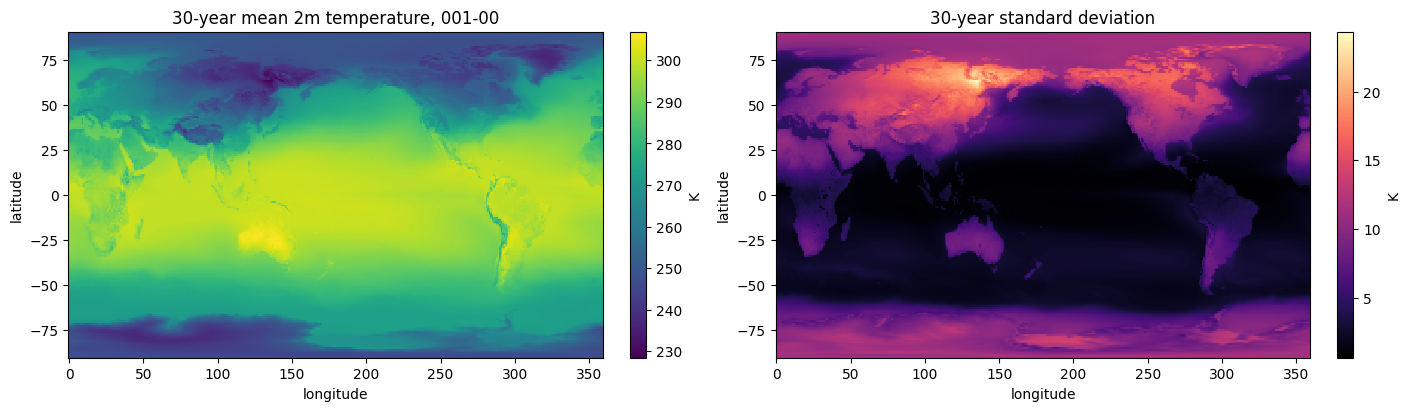

mean field: 228.4 to 306.9 K
std dev:    0.64 to 24.35 K
seasonal cycle has 1464 six-hourly slots


In [20]:
import xarray
import matplotlib.pyplot as plt

WHEN = "001-00"   # day-of-year and hour, as stored in the 'strftime' coordinate

clim_mean = xarray.open_dataset(
    f"{DATA_DIR}/temp_climatology_timeseries_1992_to_2021.nc")["2m_temperature"]
clim_std = xarray.open_dataset(
    f"{DATA_DIR}/std_dev_30yr_climatology_1992_to_2021.nc")["2m_temperature"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# pcolormesh is given the lat/lon coordinates rather than being handed a bare
# array, so it orients itself -- latitude is stored south-to-north here.
panels = [
    (clim_mean.sel(strftime=WHEN), f"30-year mean 2m temperature, {WHEN}", "K", "viridis"),
    (clim_std, "30-year standard deviation", "K", "magma"),
]
for ax, (field, title, unit, cmap) in zip(axes, panels):
    pcm = ax.pcolormesh(field.longitude, field.latitude, field, cmap=cmap, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    fig.colorbar(pcm, ax=ax, label=unit)

plt.show()

print(f"mean field: {float(clim_mean.sel(strftime=WHEN).min()):.1f} to "
      f"{float(clim_mean.sel(strftime=WHEN).max()):.1f} K")
print(f"std dev:    {float(clim_std.min()):.2f} to {float(clim_std.max()):.2f} K")
print(f"seasonal cycle has {clim_mean.sizes['strftime']} six-hourly slots")
